# **Importacion**


In [ ]:
!pip install langdetect

In [ ]:
import pandas as pd
from langdetect import detect


import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.tag import pos_tag
from nltk.probability import FreqDist


In [ ]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("names")
nltk.download("wordnet")
nltk.download('averaged_perceptron_tagger')
nltk.download('tagsets')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Package names is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package

True

In [ ]:
STOPWORDS = nltk.corpus.stopwords.words("english")
NAMES = nltk.corpus.names.words()

# Analisis exploratorio de la data

In [ ]:
df = pd.read_csv('DisneylandReviews.csv', encoding='latin1', engine='python', on_bad_lines='skip')
#obtenido de https://www.kaggle.com/datasets/arushchillar/disneyland-reviews

In [ ]:
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [ ]:
print(df.loc[0, 'Review_Text'])

If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street! It has a very familiar feel. One of the rides  its a Small World  is absolutely fabulous and worth doing. The day we visited was fairly hot and relatively busy but the queues moved fairly well. 


<Axes: xlabel='Rating'>

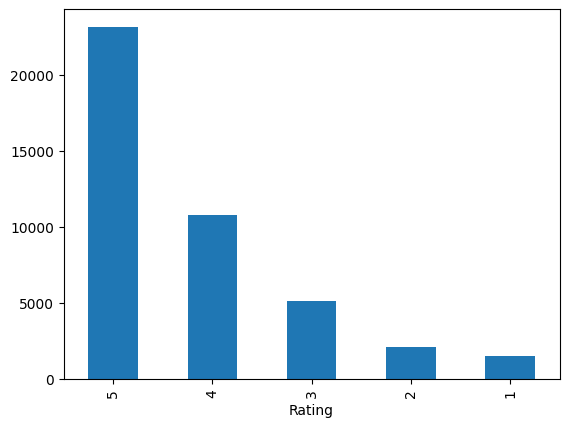

In [ ]:
df["Rating"].value_counts().plot(kind= "bar")

In [ ]:
df["sentiment"] = df["Rating"].apply(lambda x: "positive" if x > 3 else "negative")
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive
...,...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris,positive
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris,positive
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris,positive
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris,positive


<Axes: xlabel='sentiment'>

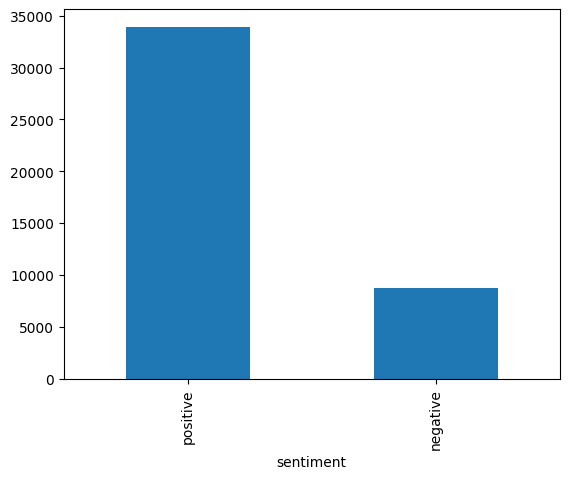

In [ ]:
df["sentiment"].value_counts().plot(kind= "bar")

In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,33921
negative,8735


In [ ]:
df["sentiment"].value_counts(normalize= True)

,proportion
sentiment,
positive,0.795222
negative,0.204778


In [ ]:
min_size_of_target_class = df["sentiment"].value_counts().min()

df = pd.concat([
    df[df["sentiment"] == target].sample(min_size_of_target_class) for target in df["sentiment"].unique()
])
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment
15245,384919074,5,2016-6,United States,We took 6 kids and they all had a great time. ...,Disneyland_California,positive
12163,522291211,5,2017-9,Canada,I recommend showing up at least 45 minutes pri...,Disneyland_California,positive
12915,483455282,5,2017-5,United States,"I always give dland 5 stars, although I wasn't...",Disneyland_California,positive
12508,500636800,4,2017-6,Australia,Thoroughly enjoyable. Recommend the 5 day park...,Disneyland_California,positive
29437,639599397,4,2018-12,South Africa,Glad that I got the 1 day 1 park pass because ...,Disneyland_Paris,positive
...,...,...,...,...,...,...,...
18079,298871331,3,2015-8,United States,I do believe that Disneyland lives up to the c...,Disneyland_California,negative
42285,51510796,2,missing,Ireland,I have brought my family to Disney's parks in ...,Disneyland_Paris,negative
39821,159687857,1,2013-5,Croatia,"Too expensive, too ordinary, too booring, dirt...",Disneyland_Paris,negative
37513,229464233,1,2014-8,United Kingdom,"This place is awful, no other word for it, ext...",Disneyland_Paris,negative


In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,8735
negative,8735


In [ ]:
df["sentiment"].value_counts(normalize= True)

,proportion
sentiment,
positive,0.5
negative,0.5


In [ ]:
#Analisis de lenguaje
df["language"]= df["Review_Text"].apply(lambda x: detect(x))
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language
15245,384919074,5,2016-6,United States,We took 6 kids and they all had a great time. ...,Disneyland_California,positive,en
12163,522291211,5,2017-9,Canada,I recommend showing up at least 45 minutes pri...,Disneyland_California,positive,en
12915,483455282,5,2017-5,United States,"I always give dland 5 stars, although I wasn't...",Disneyland_California,positive,en
12508,500636800,4,2017-6,Australia,Thoroughly enjoyable. Recommend the 5 day park...,Disneyland_California,positive,en
29437,639599397,4,2018-12,South Africa,Glad that I got the 1 day 1 park pass because ...,Disneyland_Paris,positive,en
...,...,...,...,...,...,...,...,...
18079,298871331,3,2015-8,United States,I do believe that Disneyland lives up to the c...,Disneyland_California,negative,en
42285,51510796,2,missing,Ireland,I have brought my family to Disney's parks in ...,Disneyland_Paris,negative,en
39821,159687857,1,2013-5,Croatia,"Too expensive, too ordinary, too booring, dirt...",Disneyland_Paris,negative,en
37513,229464233,1,2014-8,United Kingdom,"This place is awful, no other word for it, ext...",Disneyland_Paris,negative,en


In [ ]:
df["language"].value_counts()

,count
language,
en,17468
no,1
nl,1


In [ ]:
#Viendo filas a eliminar
df[df["language"] != "en"]

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language
26721,129785502,5,2012-5,Australia,"Everything , rides fun some old but still enjo...",Disneyland_California,positive,no
30690,565264346,3,2018-2,Netherlands,"Beautiful parks, but it has many outdated attr...",Disneyland_Paris,negative,nl


In [ ]:
#Nuevo dataframe completo en ingles
df = df[df["language"] == "en"]
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language
15245,384919074,5,2016-6,United States,We took 6 kids and they all had a great time. ...,Disneyland_California,positive,en
12163,522291211,5,2017-9,Canada,I recommend showing up at least 45 minutes pri...,Disneyland_California,positive,en
12915,483455282,5,2017-5,United States,"I always give dland 5 stars, although I wasn't...",Disneyland_California,positive,en
12508,500636800,4,2017-6,Australia,Thoroughly enjoyable. Recommend the 5 day park...,Disneyland_California,positive,en
29437,639599397,4,2018-12,South Africa,Glad that I got the 1 day 1 park pass because ...,Disneyland_Paris,positive,en
...,...,...,...,...,...,...,...,...
18079,298871331,3,2015-8,United States,I do believe that Disneyland lives up to the c...,Disneyland_California,negative,en
42285,51510796,2,missing,Ireland,I have brought my family to Disney's parks in ...,Disneyland_Paris,negative,en
39821,159687857,1,2013-5,Croatia,"Too expensive, too ordinary, too booring, dirt...",Disneyland_Paris,negative,en
37513,229464233,1,2014-8,United Kingdom,"This place is awful, no other word for it, ext...",Disneyland_Paris,negative,en


In [ ]:
df["prompt_length"] = df["Review_Text"].apply(lambda x: len(x))
df

/tmp/ipython-input-808850344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["prompt_length"] = df["Review_Text"].apply(lambda x: len(x))


,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language,prompt_length
15245,384919074,5,2016-6,United States,We took 6 kids and they all had a great time. ...,Disneyland_California,positive,en,189
12163,522291211,5,2017-9,Canada,I recommend showing up at least 45 minutes pri...,Disneyland_California,positive,en,732
12915,483455282,5,2017-5,United States,"I always give dland 5 stars, although I wasn't...",Disneyland_California,positive,en,144
12508,500636800,4,2017-6,Australia,Thoroughly enjoyable. Recommend the 5 day park...,Disneyland_California,positive,en,196
29437,639599397,4,2018-12,South Africa,Glad that I got the 1 day 1 park pass because ...,Disneyland_Paris,positive,en,258
...,...,...,...,...,...,...,...,...,...
18079,298871331,3,2015-8,United States,I do believe that Disneyland lives up to the c...,Disneyland_California,negative,en,831
42285,51510796,2,missing,Ireland,I have brought my family to Disney's parks in ...,Disneyland_Paris,negative,en,1077
39821,159687857,1,2013-5,Croatia,"Too expensive, too ordinary, too booring, dirt...",Disneyland_Paris,negative,en,374
37513,229464233,1,2014-8,United Kingdom,"This place is awful, no other word for it, ext...",Disneyland_Paris,negative,en,4542


In [ ]:
# Revisa los outliers en términos de tamaño
df[df["prompt_length"] < 55]

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language,prompt_length
8999,124459435,5,missing,Singapore,"excellent place, accomodating people, exciting...",Disneyland_HongKong,positive,en,52
41731,120192148,5,2011-11,United Kingdom,Excellent place for young or old fantasy land ...,Disneyland_Paris,positive,en,53
26389,133309894,5,2012-6,United States,Can never get enough of Disney! Cars land was...,Disneyland_California,positive,en,53
26960,127309701,5,2012-3,United States,"Pretty crowded, but always fun. We love Disney...",Disneyland_California,positive,en,51
9222,120886952,5,2011-10,Philippines,the best for kids and also the young at heart(...,Disneyland_HongKong,positive,en,52
27905,121611861,4,2011-12,Canada,Disney was very crowded but that is to be expe...,Disneyland_California,positive,en,51
41556,123923633,5,2012-1,United Kingdom,all rides were brilliant kids and adults had...,Disneyland_Paris,positive,en,53
27398,124947569,2,missing,United States,Too many people; too many long lines; too expe...,Disneyland_California,negative,en,52
41466,125602048,3,2012-2,United Kingdom,Disappointed with size compared to florida cou...,Disneyland_Paris,negative,en,54


In [ ]:
df = df[df["prompt_length"] > 50]
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language,prompt_length
15245,384919074,5,2016-6,United States,We took 6 kids and they all had a great time. ...,Disneyland_California,positive,en,189
12163,522291211,5,2017-9,Canada,I recommend showing up at least 45 minutes pri...,Disneyland_California,positive,en,732
12915,483455282,5,2017-5,United States,"I always give dland 5 stars, although I wasn't...",Disneyland_California,positive,en,144
12508,500636800,4,2017-6,Australia,Thoroughly enjoyable. Recommend the 5 day park...,Disneyland_California,positive,en,196
29437,639599397,4,2018-12,South Africa,Glad that I got the 1 day 1 park pass because ...,Disneyland_Paris,positive,en,258
...,...,...,...,...,...,...,...,...,...
18079,298871331,3,2015-8,United States,I do believe that Disneyland lives up to the c...,Disneyland_California,negative,en,831
42285,51510796,2,missing,Ireland,I have brought my family to Disney's parks in ...,Disneyland_Paris,negative,en,1077
39821,159687857,1,2013-5,Croatia,"Too expensive, too ordinary, too booring, dirt...",Disneyland_Paris,negative,en,374
37513,229464233,1,2014-8,United Kingdom,"This place is awful, no other word for it, ext...",Disneyland_Paris,negative,en,4542


# Preprocesamiento de texto

In [ ]:
def get_tokens(review, simplifier_func=None):
    tokens = word_tokenize(review)
    cleaned_tokens = []
    for token in tokens:
        if not token.isalpha(): continue
        if token in NAMES: continue
        token = token.lower()
        if token in STOPWORDS: continue
        if pos_tag([token])[0][1][:2] not in ["NN", "VB", "JJ", "RB"]: continue
        if simplifier_func: token = lemmatizer.lemmatize(token)
        cleaned_tokens.append(token)
    return cleaned_tokens

In [ ]:
df['tokens'] = df["Review_Text"].apply(lambda x: get_tokens(x))
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language,prompt_length,tokens
15245,384919074,5,2016-6,United States,We took 6 kids and they all had a great time. ...,Disneyland_California,positive,en,189,"[took, kids, great, time, characters, spent, l..."
12163,522291211,5,2017-9,Canada,I recommend showing up at least 45 minutes pri...,Disneyland_California,positive,en,732,"[recommend, showing, least, minutes, prior, pa..."
12915,483455282,5,2017-5,United States,"I always give dland 5 stars, although I wasn't...",Disneyland_California,positive,en,144,"[always, give, dland, stars, happy, indiana, j..."
12508,500636800,4,2017-6,Australia,Thoroughly enjoyable. Recommend the 5 day park...,Disneyland_California,positive,en,196,"[thoroughly, enjoyable, recommend, day, park, ..."
29437,639599397,4,2018-12,South Africa,Glad that I got the 1 day 1 park pass because ...,Disneyland_Paris,positive,en,258,"[got, day, park, pass, managed, park, pass, at..."
...,...,...,...,...,...,...,...,...,...,...
18079,298871331,3,2015-8,United States,I do believe that Disneyland lives up to the c...,Disneyland_California,negative,en,831,"[believe, disneyland, lives, claim, happiest, ..."
42285,51510796,2,missing,Ireland,I have brought my family to Disney's parks in ...,Disneyland_Paris,negative,en,1077,"[brought, family, disney, parks, california, p..."
39821,159687857,1,2013-5,Croatia,"Too expensive, too ordinary, too booring, dirt...",Disneyland_Paris,negative,en,374,"[expensive, ordinary, booring, dirty, well, de..."
37513,229464233,1,2014-8,United Kingdom,"This place is awful, no other word for it, ext...",Disneyland_Paris,negative,en,4542,"[place, awful, word, extortionate, prices, hor..."


# Comprension del vocabulario





In [ ]:
from collections import Counter

# Unir todas las reviews en un solo texto
# Flatten the list of lists into a single list of words
all_words = [word for review_list in df['tokens'] for word in review_list]

# Count the frequency of each word
vocabulario = Counter(all_words)

# Ver las 10 palabras más comunes
print(vocabulario.most_common(10))

[('park', 17952), ('disney', 17222), ('rides', 15472), ('disneyland', 13894), ('time', 12136), ('day', 11704), ('get', 10193), ('go', 8913), ('ride', 7931), ('food', 6637)]


In [ ]:
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language,prompt_length,tokens
15245,384919074,5,2016-6,United States,We took 6 kids and they all had a great time. ...,Disneyland_California,positive,en,189,"[took, kids, great, time, characters, spent, l..."
12163,522291211,5,2017-9,Canada,I recommend showing up at least 45 minutes pri...,Disneyland_California,positive,en,732,"[recommend, showing, least, minutes, prior, pa..."
12915,483455282,5,2017-5,United States,"I always give dland 5 stars, although I wasn't...",Disneyland_California,positive,en,144,"[always, give, dland, stars, happy, indiana, j..."
12508,500636800,4,2017-6,Australia,Thoroughly enjoyable. Recommend the 5 day park...,Disneyland_California,positive,en,196,"[thoroughly, enjoyable, recommend, day, park, ..."
29437,639599397,4,2018-12,South Africa,Glad that I got the 1 day 1 park pass because ...,Disneyland_Paris,positive,en,258,"[got, day, park, pass, managed, park, pass, at..."
...,...,...,...,...,...,...,...,...,...,...
18079,298871331,3,2015-8,United States,I do believe that Disneyland lives up to the c...,Disneyland_California,negative,en,831,"[believe, disneyland, lives, claim, happiest, ..."
42285,51510796,2,missing,Ireland,I have brought my family to Disney's parks in ...,Disneyland_Paris,negative,en,1077,"[brought, family, disney, parks, california, p..."
39821,159687857,1,2013-5,Croatia,"Too expensive, too ordinary, too booring, dirt...",Disneyland_Paris,negative,en,374,"[expensive, ordinary, booring, dirty, well, de..."
37513,229464233,1,2014-8,United Kingdom,"This place is awful, no other word for it, ext...",Disneyland_Paris,negative,en,4542,"[place, awful, word, extortionate, prices, hor..."


In [ ]:
import pandas as pd
from langdetect import detect
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.tag import pos_tag
from nltk.probability import FreqDist

# Load the data
df = pd.read_csv('DisneylandReviews.csv', encoding='latin1')

# Apply sentiment and language filtering
df["sentiment"] = df["Rating"].apply(lambda x: "positive" if x > 3 else "negative")
min_size_of_target_class = df["sentiment"].value_counts().min()
df = pd.concat([
    df[df["sentiment"] == target].sample(min_size_of_target_class) for target in df["sentiment"].unique()
])
df["language"]= df["Review_Text"].apply(lambda x: detect(x))
df = df[df["language"] == "en"]
df["prompt_length"] = df["Review_Text"].apply(lambda x: len(x))
df = df[df["prompt_length"] > 50]


# Define get_tokens function (assuming it's needed for this part)
lemmatizer = WordNetLemmatizer()
def get_tokens(review, simplifier_func=None):
    tokens = word_tokenize(review)
    cleaned_tokens = []
    for token in tokens:
        if not token.isalpha(): continue
        # Assuming NAMES and STOPWORDS are defined globally or imported
        if token in nltk.corpus.names.words(): continue
        token = token.lower()
        if token in nltk.corpus.stopwords.words("english"): continue
        if pos_tag([token])[0][1][:2] not in ["NN", "VB", "JJ", "RB"]: continue
        if simplifier_func: token = simplifier_func(token) # Use simplifier_func if provided
        cleaned_tokens.append(token)
    return cleaned_tokens

df['tokens'] = df["Review_Text"].apply(lambda x: get_tokens(x, simplifier_func=lemmatizer))


# Vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Unimos los tokens en texto plano
df["joined_tokens"] = df["tokens"].apply(lambda x: " ".join(x))

# --- CountVectorizer (Bolsa de Palabras)
bow_vectorizer = CountVectorizer(min_df=2)
X_bow = bow_vectorizer.fit_transform(df["joined_tokens"])

print("Shape del BOW:", X_bow.shape)

# --- Binary CountVectorizer
binary_vectorizer = CountVectorizer(binary=True, min_df=2)
X_binary = binary_vectorizer.fit_transform(df["joined_tokens"])

print("Shape del Binary TF:", X_binary.shape)

# --- TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(min_df=2)
X_tfidf = tfidf_vectorizer.fit_transform(df["joined_tokens"])

print("Shape del TF-IDF:", X_tfidf.shape)

TypeError: 'WordNetLemmatizer' object is not callable

In [ ]:
!pip install langdetect

#Entrenamiento

In [ ]:
"""
train_and_eval.py
Entrena 6 clasificadores usando 3 vectorizadores diferentes sobre las reviews,
realiza búsqueda de hiperparámetros, evalúa métricas y guarda artefactos.
Salida:
 - modelos y vectorizadores en ./artifacts/ como .joblib
 - reporte completo en ./artifacts/metrics_report.csv
"""

from typing import Dict, Tuple, Any, List
import os
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.preprocessing import FunctionTransformer


# Crear carpeta para artefactos
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)


# Removed the load_data function as the data is already loaded

def to_dense_transformer(x):
    """Converts sparse matrix to dense array."""
    return x.toarray()

def get_vectorizers() -> Dict[str, Any]:
    """Devuelve los 3 vectorizadores solicitados."""
    return {
        "binary_tf": CountVectorizer(binary=True, min_df=2),
        "bow": CountVectorizer(binary=False, min_df=2),
        "tfidf": TfidfVectorizer(min_df=2)
    }


def get_model_param_grids() -> Dict[str, Tuple[Any, Dict[str, List[Any]]]]:
    """Define los modelos y sus grids de hiperparámetros."""
    return {
        "KNeighbors": (
            KNeighborsClassifier(),
            {"clf__n_neighbors": [3, 5, 7], "clf__weights": ["uniform", "distance"]}
        ),
        "RandomForest": (
            RandomForestClassifier(random_state=42),
            {"clf__n_estimators": [100, 200], "clf__max_depth": [None, 20]}
        ),
        "DecisionTree": (
            DecisionTreeClassifier(random_state=42),
            {"clf__max_depth": [None, 10, 20], "clf__min_samples_split": [2, 5]}
        ),
        "GaussianNB": (
            GaussianNB(),
            {"clf__var_smoothing": [1e-9, 1e-8, 1e-7]}
        ),
        "MultinomialNB": (
            MultinomialNB(),
            {"clf__alpha": [0.5, 1.0]}
        ),
        "AdaBoost": (
            AdaBoostClassifier(random_state=42),
            {"clf__n_estimators": [50, 100], "clf__learning_rate": [0.5, 1.0]}
        ),
    }


def evaluate_and_report(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, Any]:
    """Calcula métricas principales y devuelve un diccionario con resultados."""
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    report = classification_report(y_true, y_pred, zero_division=0)
    return {
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "classification_report": report
    }


def train_all(df: pd.DataFrame): # Added df as a parameter
    """
    Flujo principal: carga datos, divide, entrena 18 combinaciones (6 modelos x 3 vectores),
    realiza GridSearch por cada combinación, guarda modelos y genera reporte.
    """
    # Removed the load_data call
    X = df["tokens"].apply(lambda x: ' '.join(x)).astype(str) # Use Review_Lemmatized and join tokens
    y = df["Rating"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    vectorizers = get_vectorizers()
    model_grids = get_model_param_grids()
    metrics_rows = []

    for vec_name, vec in vectorizers.items():
        for model_name, (estimator, param_grid) in model_grids.items():
            print(f"\nEntrenando: Vectorizador={vec_name} | Modelo={model_name}")


            if model_name == "GaussianNB":
                pipeline = Pipeline([
                    ("vect", vec),
                    ("to_dense", FunctionTransformer(to_dense_transformer, accept_sparse=True)), # Use the top-level function
                    ("clf", estimator)
                ])
            else:
                pipeline = Pipeline([
                    ("vect", vec),
                    ("clf", estimator)
                ])

            gs = GridSearchCV(pipeline, param_grid=param_grid, cv=3, n_jobs=-1, verbose=0)
            gs.fit(X_train, y_train)

            best = gs.best_estimator_
            y_pred = best.predict(X_test)
            metrics = evaluate_and_report(y_test, y_pred)

            artifact_name = f"{model_name}__{vec_name}.joblib"
            artifact_path = os.path.join(ARTIFACTS_DIR, artifact_name)
            joblib.dump(best, artifact_path)

            print(f"Guardado: {artifact_path}")
            print("Mejores params:", gs.best_params_)
            print("Accuracy:", metrics["accuracy"])
            print(metrics["classification_report"])

            metrics_rows.append({
                "model": model_name,
                "vectorizer": vec_name,
                "artifact_path": artifact_path,
                "best_params": gs.best_params_,
                "accuracy": metrics["accuracy"],
                "precision_weighted": metrics["precision_weighted"],
                "recall_weighted": metrics["recall_weighted"],
                "f1_weighted": metrics["f1_weighted"],
                "classification_report": metrics["classification_report"]
            })

    metrics_df = pd.DataFrame(metrics_rows)
    metrics_csv = os.path.join(ARTIFACTS_DIR, "metrics_report.csv")
    metrics_df.to_csv(metrics_csv, index=False)
    print(f"\n✅ Reporte guardado en {metrics_csv}")


if __name__ == "__main__":
    train_all(df) # Pass the existing df to the function

# API

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List
import joblib


MODEL_PATH = "artifacts/RandomForest__tfidf.joblib"


print(f"Cargando modelo desde: {MODEL_PATH}")
model = joblib.load(MODEL_PATH)
print("✅ Modelo cargado correctamente")


class ReviewInput(BaseModel):
    texto: str

class BatchInput(BaseModel):
    textos: List[str]


app = FastAPI(
    title="API de Clasificación de Reviews",
    description="Clasifica comentarios como positivos o negativos usando un modelo entrenado.",
    version="2.0.0"
)


def interpretar_pred(pred):
    """
    Convierte la predicción numérica en texto:
    1–2 -> negativo
    3–5 -> positivo
    """
    try:
        pred = int(pred)
        return "positivo 😄" if pred >= 3 else "negativo 😡"
    except:
        if str(pred).lower() in ["negativo", "negative"]:
            return "negativo 😡"
        return "positivo 😄"


@app.post("/predict/")
def predecir_sentimiento(review: ReviewInput):
    texto = review.texto
    pred = model.predict([texto])[0]
    resultado = interpretar_pred(pred)
    return {
        "texto": texto,
        "prediccion": resultado
    }


@app.post("/predict_batch/")
def predecir_varios(batch: BatchInput):
    textos = batch.textos
    preds = model.predict(textos)
    resultados = [
        {"texto": txt, "prediccion": interpretar_pred(pred)}
        for txt, pred in zip(textos, preds)
    ]
    return {"total": len(textos), "resultados": resultados}


@app.get("/")
def root():
    return {"mensaje": "🚀 API de clasificación de reviews activa. Usa /predict o /predict_batch para probar."}

In [ ]:
# Install ngrok
!pip install pyngrok

In [ ]:
df["tokens"]

In [ ]:
from pyngrok import ngrok


Now you can use the `Public URL` to access your FastAPI application from anywhere! Append `/docs` to the public URL to view the Swagger UI and test your endpoints.